In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize

In [4]:
# load and view data
ds = xr.open_dataset('xboutput.nc')
ds

<xarray.Dataset> Size: 187GB
Dimensions:      (globaltime: 1801, ny: 1001, nx: 1083, sediment_classes: 1)
Coordinates:
  * globaltime   (globaltime) float64 14kB 0.0 2.0 4.0 ... 3.598e+03 3.6e+03
    globalx      (ny, nx) float64 9MB ...
    globaly      (ny, nx) float64 9MB ...
Dimensions without coordinates: ny, nx, sediment_classes
Data variables: (12/13)
    _parameters  float64 8B ...
    zs           (globaltime, ny, nx) float64 16GB ...
    zb           (globaltime, ny, nx) float64 16GB ...
    H            (globaltime, ny, nx) float64 16GB ...
    ue           (globaltime, ny, nx) float64 16GB ...
    ve           (globaltime, ny, nx) float64 16GB ...
    ...           ...
    Susg         (globaltime, sediment_classes, ny, nx) float64 16GB ...
    Svbg         (globaltime, sediment_classes, ny, nx) float64 16GB ...
    Svsg         (globaltime, sediment_classes, ny, nx) float64 16GB ...
    dzsdx        (globaltime, ny, nx) float64 16GB ...
    dzsdy        (globaltime, ny, nx) float64 16GB ...
    sedero       (globaltime, ny, nx) float64 16GB ...
Attributes:
    Conventions:     CF-1.4
    Producer:        XBeach littoral zone wave model (http://www.xbeach.org)
    Build-Revision:  
    Build-Date:      Mon Mar  2 01:09:57 PM EST 2026
    URL:

In [ ]:
# 2d animation
x = ds['globalx']
y = ds['globaly']
time = ds['globaltime']

fig, ax = plt.subplots(figsize=(10, 6))

# vmin = float(ds['zs'].min())
vmin = -float(ds['zs'].max())
vmax = float(ds['zs'].max())
norm = TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)

quad = ax.pcolormesh(ds.globalx, ds.globaly, ds['zs'].isel(globaltime=0), norm=norm, cmap='RdBu', shading='auto')

fig.colorbar(quad, label='Water Level Surface ($m$)')
ax.set_title('Wave Field (Red=Trough, Blue=Crest)')

def update(frame):
    quad.set_array(ds['zs'].isel(globaltime=frame).values.ravel())
    ax.set_title(f"Time: {ds.globaltime[frame].values:.1f}s")
    return quad,

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=True)
ani.save('wave_animation.gif', writer='pillow', fps=10)
print("Animation saved as wave_animation.gif")

In [ ]:
# 3d animation
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

bed = ds['zb'].isel(globaltime=0).values

def update(frame):
    ax.clear()
    surface_deviation = ds['zs'].isel(globaltime=frame).values
    ax.plot_surface(X_mesh, Y_mesh, bed, cmap='YlOrBr_r', linewidth=0, antialiased=True)
    surf = ax.plot_surface(X_mesh, Y_mesh, surface_deviation, cmap='Blues', linewidth=0, antialiased=False, alpha=0.7)
    ax.set_zlim(np.min(bed)-0.5, 1.5)
    ax.set_title(f"3D Wave Field | Time: {ds.globaltime[frame].values:.1f}s")
    ax.view_init(elev=25, azim=-110)
    return surf,

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=False)
ani.save('wave_3d_final.gif', writer='pillow', fps=6)
print("3D Animation saved as wave_3d_final.gif")

In [ ]:
# plot sediment flux vector field
fig, ax = plt.subplots(figsize=(17, 9))

background = ds['zs'].isel(globaltime=0)
im = ax.pcolormesh(X_mesh, Y_mesh, background, cmap='RdBu', shading='auto')
fig.colorbar(im, label='Wave Height H ($m$)')

skip = (slice(None, None, 5), slice(None, None, 10)) 

# squeeze dimension 
u_full = ds['Susg'].isel(globaltime=-1).values.squeeze()
v_full = ds['Svsg'].isel(globaltime=-1).values.squeeze()

X_plot = X_mesh[skip]
Y_plot = Y_mesh[skip]
u_plot = u_full[skip]
v_plot = v_full[skip]

Q = ax.quiver(X_plot, Y_plot, u_plot, v_plot, color='k', scale=1, width=0.002)

# cbar = fig.colorbar(Q, ax=ax, label='Sediment Transport Magnitude (m²/s)')
ax.set_title('Sediment Flux')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')

def update(frame):
    im.set_array(ds['zs'].isel(globaltime=frame).values.ravel())
    
    u = ds['Susg'].isel(globaltime=frame).values.squeeze()[skip]
    v = ds['Svsg'].isel(globaltime=frame).values.squeeze()[skip]
    Q.set_UVC(u, v)
    
    ax.set_title(f"Sediment Flux | Time: {ds.globaltime[frame].values:.1f}s")
    return im, Q

ani = animation.FuncAnimation(fig, update, frames=len(ds.globaltime), blit=False)
ani.save('sediment_vectors.gif', writer='pillow', fps=8)
print("Sediment vector animation saved as sediment_vectors.gif")

In [1]:
#change vectors to susg/svsg change background to sedero
time = ds['globaltime'].values
dt = np.diff(time) 
dt = np.append(dt, dt[-1]) 

u_sum = (ds['Susg'] * dt[:, np.newaxis, np.newaxis]).sum(dim='globaltime').values
v_sum = (ds['Svsg'] * dt[:, np.newaxis, np.newaxis]).sum(dim='globaltime').values

mag_sum = np.sqrt(u_sum**2 + v_sum**2)

fig, ax = plt.subplots(figsize=(15, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, mag_sum, cmap='YlOrRd', shading='auto')
cbar = fig.colorbar(im, label='Total Advection ($m^2$)') #THESE UNITS ARE WRONG

skip = (slice(None, None, 10), slice(None, None, 10))
Q = ax.quiver(X_mesh[skip], Y_mesh[skip], u_sum[skip], v_sum[skip], color='black', scale_units='xy', angles='xy')

ax.set_title('Net Cumulative Sediment Advection')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
plt.show()

NameError: name 'ds' is not defined

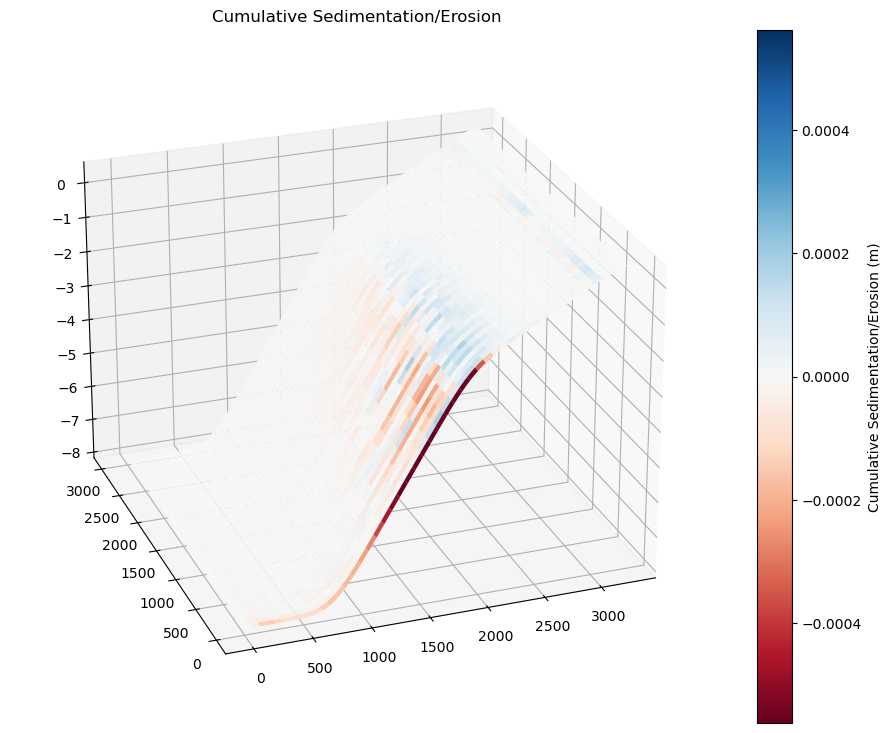

In [7]:
sedero = ds['sedero'].isel(globaltime=-1).values

limit = .5*max(abs(sedero.min()), abs(sedero.max()))
norm = Normalize(vmin=-limit, vmax=limit)

colors = cm.RdBu(norm(sedero))

fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X_mesh, Y_mesh, bed, facecolors=colors, linewidth=0, antialiased=True, shade=False)

m = cm.ScalarMappable(cmap=cm.RdBu, norm=norm)
m.set_array(sedero)
fig.colorbar(m, ax=ax, label='Cumulative Sedimentation/Erosion (m)')

ax.set_title('Cumulative Sedimentation/Erosion')
ax.view_init(elev=25, azim=-110)
plt.show()

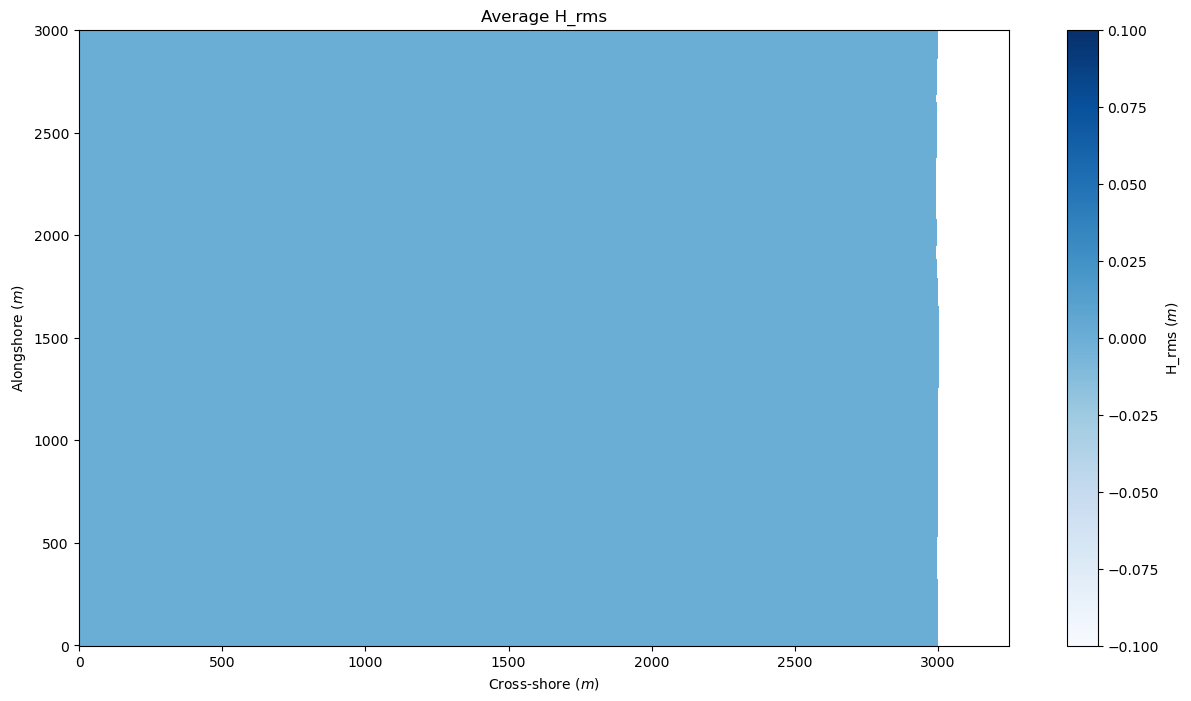

In [6]:
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

H_rms_mean = ds['H'].mean(dim='globaltime').values

fig, ax = plt.subplots(figsize=(15, 8))

im = ax.pcolormesh(X_mesh, Y_mesh, H_rms_mean, cmap='Blues', shading='auto')
cbar = fig.colorbar(im, label='H_rms ($m$)')

ax.set_title('Average H_rms')
ax.set_xlabel('Cross-shore ($m$)')
ax.set_ylabel('Alongshore ($m$)')
plt.show()

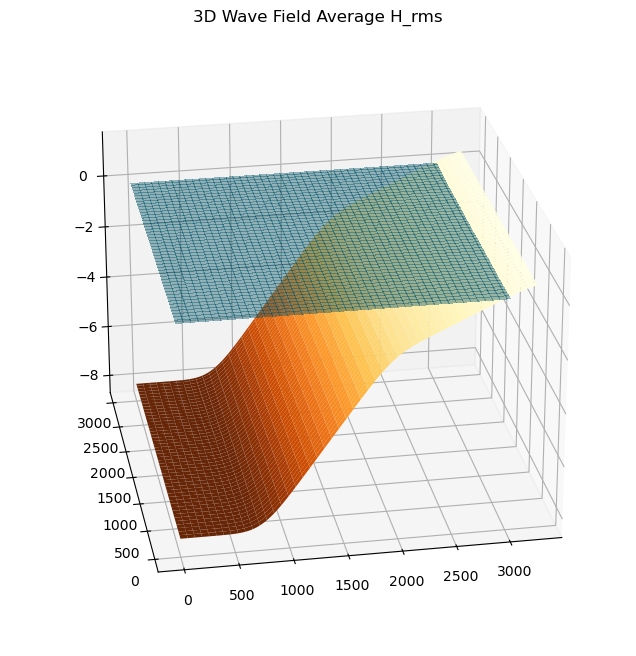

In [10]:
# 3d h_rms plot
X = ds['globalx'].isel(ny=0).values  # slice along the ny dimension
Y = ds['globaly'].isel(nx=0).values  # slice along the nx dimension
X_mesh, Y_mesh = np.meshgrid(X, Y)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

bed = ds['zb'].isel(globaltime=0).values
H_rms_mean = ds['H'].mean(dim='globaltime').values
ax.plot_surface(X_mesh, Y_mesh, bed, cmap='YlOrBr_r', linewidth=0, antialiased=True)
ax.plot_surface(X_mesh, Y_mesh, H_rms_mean, color='#006884',linewidth=0, antialiased=False, alpha=0.4)
ax.set_zlim(np.min(bed)-0.5, 1.5)
ax.set_title(f"3D Wave Field Average H_rms")
ax.view_init(elev=25, azim=-100)

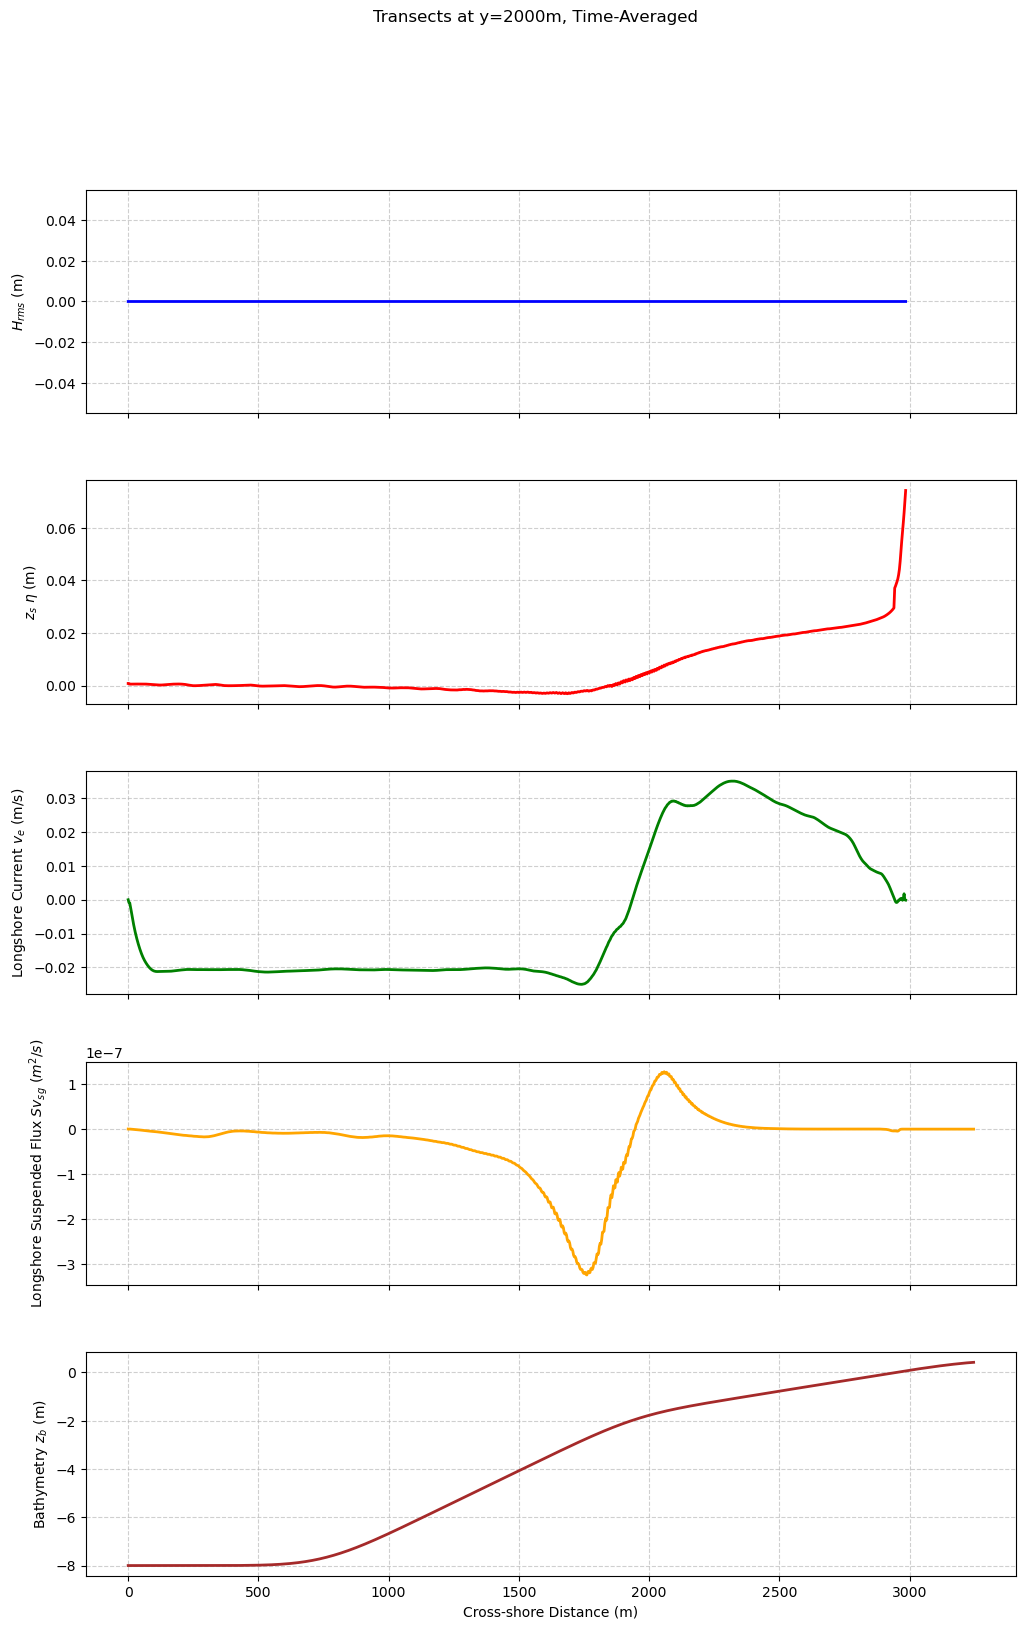

In [4]:
y_coords = ds['globaly'].isel(nx=0).values
ny_idx = np.abs(y_coords - 2000).argmin()
actual_y = y_coords[ny_idx]
x_coords = ds['globalx'].isel(ny=ny_idx).values

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
plt.subplots_adjust(hspace=0.3)

vars_to_plot = [
    ('H', '$H_{rms}$ (m)', 'blue'),
    ('zs', '$z_s$ $\eta$ (m)', 'red'),
    ('ve', 'Longshore Current $v_e$ (m/s)', 'green'),
    ('Svsg', 'Longshore Suspended Flux $Sv_{sg}$ ($m^2/s$)', 'orange'),
    ('zb', 'Bathymetry $z_b$ (m)', 'brown')
]

for i, (var_name, label, color) in enumerate(vars_to_plot):
    data_array = ds[var_name].isel(ny=ny_idx).mean(dim='globaltime')
    data = data_array.values.squeeze()

    axes[i].plot(x_coords, data, color=color, linewidth=2)
    axes[i].set_ylabel(label)
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Cross-shore Distance (m)')
fig.suptitle('Transects at y=2000m, Time-Averaged')

plt.show()

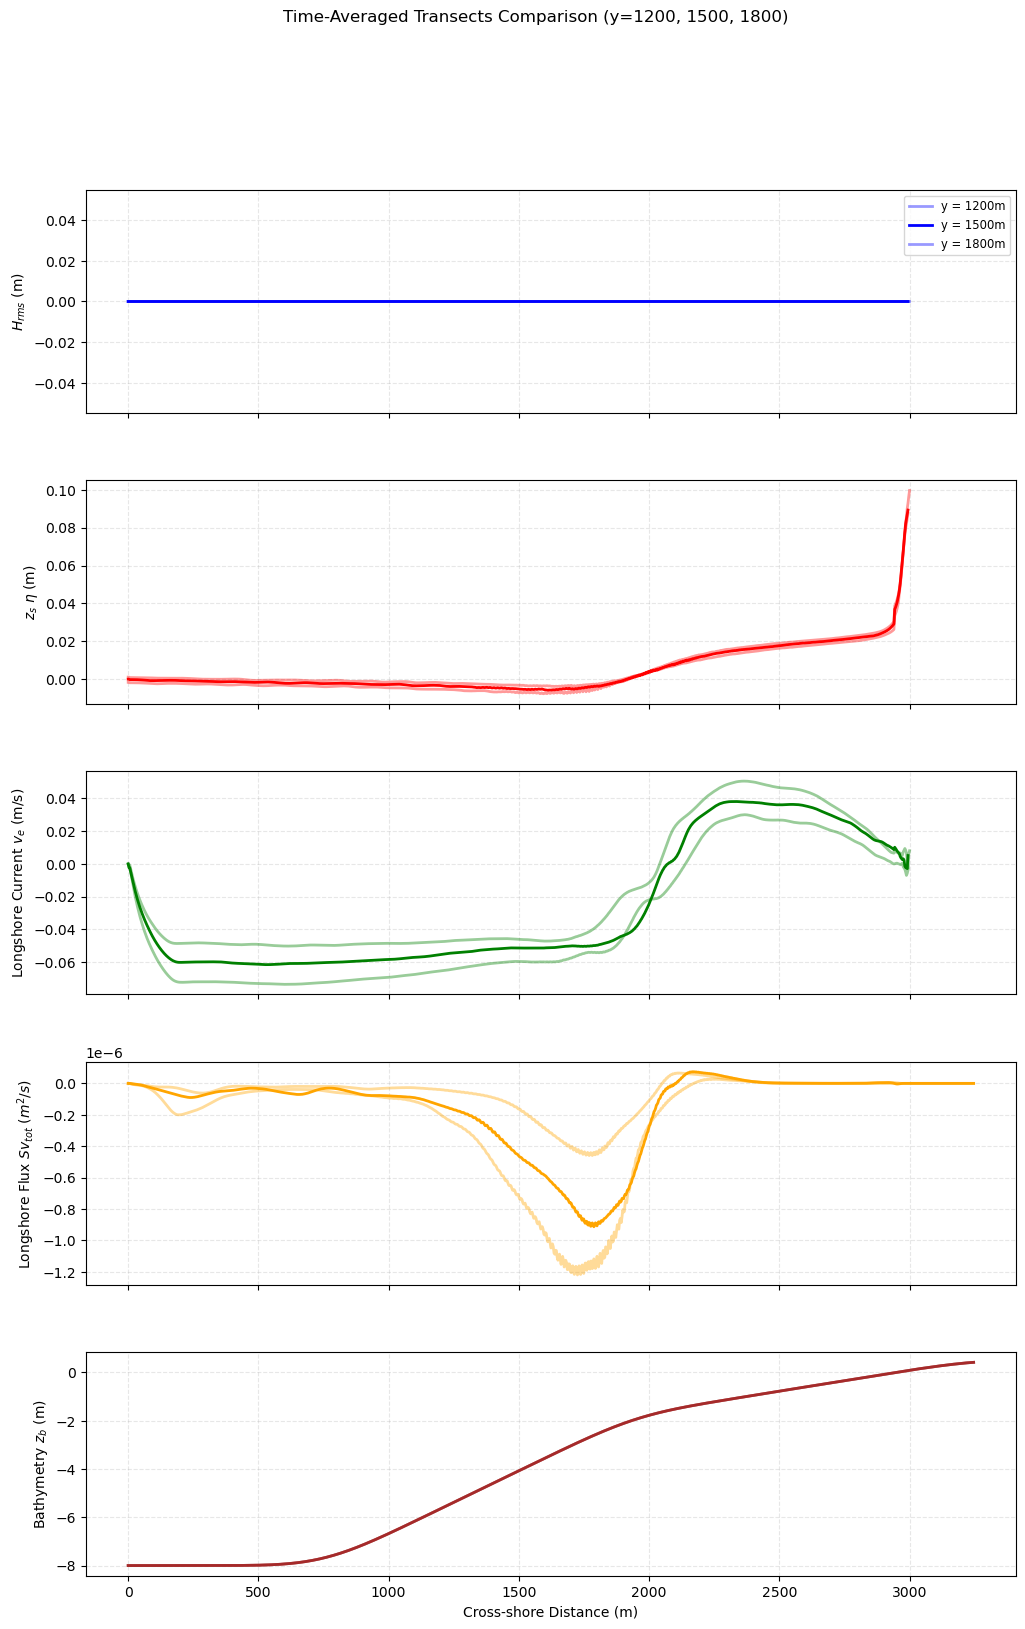

In [5]:
target_ys = [1200, 1500, 1800]
y_coords_full = ds['globaly'].isel(nx=0).values

fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=True)
plt.subplots_adjust(hspace=0.3)

vars_to_plot = [
    ('H', '$H_{rms}$ (m)', 'blue'),
    ('zs', '$z_s$ $\eta$ (m)', 'red'),
    ('ve', 'Longshore Current $v_e$ (m/s)', 'green'),
    ('Svsg', 'Longshore Flux $Sv_{tot}$ ($m^2/s$)', 'orange'),
    ('zb', 'Bathymetry $z_b$ (m)', 'brown')
]

line_styles = ['-', '-', '-']
alphas = [.4, 1.0, .4]

for j, y_target in enumerate(target_ys):
    #find the closest index for specific Y
    ny_idx = np.abs(y_coords_full - y_target).argmin()
    actual_y = y_coords_full[ny_idx]
    x_coords = ds['globalx'].isel(ny=ny_idx).values

    for i, (var_name, label, color) in enumerate(vars_to_plot):
        data_array = ds[var_name].isel(ny=ny_idx).mean(dim='globaltime')
            
        data = data_array.values.squeeze()

        axes[i].plot(x_coords, data, 
                     color=color, 
                     linestyle=line_styles[j], 
                     alpha=alphas[j],
                     linewidth=2, 
                     label=f'y = {actual_y:.0f}m')

        if j == 0:
            axes[i].set_ylabel(label)
            axes[i].grid(True, linestyle='--', alpha=0.3)

axes[0].legend(loc='upper right', fontsize='small')

axes[-1].set_xlabel('Cross-shore Distance (m)')
fig.suptitle('Time-Averaged Transects Comparison (y=1200, 1500, 1800)')

plt.show()